In [1]:
import pandas as pd
import os

In [3]:
path = '/Users/jassemtoumi/Downloads/archive'

files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("Files found:")
for f in files:
    print(f)

Files found:
Team Stats Per 100 Poss.csv
End of Season Teams (Voting).csv
Team Totals.csv
Player Per Game.csv
Advanced.csv
Draft Pick History.csv
End of Season Teams.csv
Opponent Stats Per 100 Poss.csv
Player Career Info.csv
Player Totals.csv
Player Play By Play.csv
Player Season Info.csv
All-Star Selections.csv
Team Abbrev.csv
Per 36 Minutes.csv
Opponent Stats Per Game.csv
Team Summaries.csv
Player Shooting.csv
Team Stats Per Game.csv
Per 100 Poss.csv
Opponent Totals.csv
Player Award Shares.csv


In [4]:
# Inspect Player Season Info - this should have position labels
df_info = pd.read_csv(path + "/Player Season Info.csv")

print("=== Player Season Info ===")
print("Shape:", df_info.shape)
print("\nColumns:", df_info.columns.tolist())
print("\nFirst 3 rows:")
print(df_info.head(3))

=== Player Season Info ===
Shape: (33326, 8)

Columns: ['season', 'lg', 'player', 'player_id', 'age', 'team', 'pos', 'experience']

First 3 rows:
   season   lg          player  player_id   age team  pos  experience
0    1947  BAA  John Abramovic  abramjo01  27.0  PIT  NaN           1
1    1947  BAA   Chet Aubuchon  aubucch01  30.0  DTF  NaN           1
2    1947  BAA      Norm Baker  bakerno01  23.0  CHS  NaN           1


In [5]:
# Filter to post-2000 and inspect position values
df_modern = df_info[df_info['season'] >= 2000]

print("Post-2000 records:", df_modern.shape)
print("\nPosition value counts:")
print(df_modern['pos'].value_counts())
print("\nAny nulls in pos:", df_modern['pos'].isnull().sum())

Post-2000 records: (16613, 8)

Position value counts:
pos
SG    3567
PF    3360
PG    3307
C     3270
SF    3108
Name: count, dtype: int64

Any nulls in pos: 1


In [6]:
df_stats = pd.read_csv(path + "/Player Per Game.csv")

print("Shape:", df_stats.shape)
print("\nColumns:", df_stats.columns.tolist())
print("\nFirst 3 rows:")
print(df_stats.head(3))
print("\nAny nulls per column:")
print(df_stats.isnull().sum())

Shape: (33326, 32)

Columns: ['season', 'lg', 'player', 'player_id', 'age', 'team', 'pos', 'g', 'gs', 'mp_per_game', 'fg_per_game', 'fga_per_game', 'fg_percent', 'x3p_per_game', 'x3pa_per_game', 'x3p_percent', 'x2p_per_game', 'x2pa_per_game', 'x2p_percent', 'e_fg_percent', 'ft_per_game', 'fta_per_game', 'ft_percent', 'orb_per_game', 'drb_per_game', 'trb_per_game', 'ast_per_game', 'stl_per_game', 'blk_per_game', 'tov_per_game', 'pf_per_game', 'pts_per_game']

First 3 rows:
   season   lg            player  player_id   age team pos   g    gs  \
0    2026  NBA  Precious Achiuwa  achiupr01  26.0  SAC   C  67  51.0   
1    2026  NBA      Steven Adams  adamsst01  32.0  HOU   C  32  11.0   
2    2026  NBA       Bam Adebayo  adebaba01  28.0  MIA   C  67  67.0   

   mp_per_game  ...  ft_percent  orb_per_game  drb_per_game  trb_per_game  \
0         23.4  ...       0.558           2.3           4.3           6.5   
1         22.8  ...       0.580           4.5           4.1           8.6   
2  

In [7]:
# Filter to Post-2000 and Re-check Nulls
df_modern = df_stats[df_stats['season'] >= 2000].copy()

print("Post-2000 shape:", df_modern.shape)
print("\nPosition counts:")
print(df_modern['pos'].value_counts())
print("\nNulls per column after filtering:")
print(df_modern.isnull().sum())

Post-2000 shape: (16613, 32)

Position counts:
pos
SG    3567
PF    3360
PG    3307
C     3270
SF    3108
Name: count, dtype: int64

Nulls per column after filtering:
season              0
lg                  0
player              0
player_id           0
age                 0
team                0
pos                 1
g                   0
gs                  0
mp_per_game         0
fg_per_game         0
fga_per_game        0
fg_percent        102
x3p_per_game        0
x3pa_per_game       0
x3p_percent      2182
x2p_per_game        0
x2pa_per_game       0
x2p_percent       193
e_fg_percent      102
ft_per_game         0
fta_per_game        0
ft_percent        885
orb_per_game        0
drb_per_game        0
trb_per_game        0
ast_per_game        0
stl_per_game        0
blk_per_game        0
tov_per_game        0
pf_per_game         0
pts_per_game        0
dtype: int64


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load
df_stats = pd.read_csv(path + "/Player Per Game.csv")

# Filter to post-2000
df_modern = df_stats[df_stats['season'] >= 2000].copy()

# Drop the 1 row with missing position
df_clean = df_modern.dropna(subset=['pos']).copy()

# Fill percentage nulls with 0
pct_cols = ['x3p_percent', 'ft_percent', 'x2p_percent', 
            'fg_percent', 'e_fg_percent']
df_clean[pct_cols] = df_clean[pct_cols].fillna(0)

print("df_clean ready:", df_clean.shape)
print(df_clean['pos'].value_counts())

df_clean ready: (16612, 32)
pos
SG    3567
PF    3360
PG    3307
C     3270
SF    3108
Name: count, dtype: int64


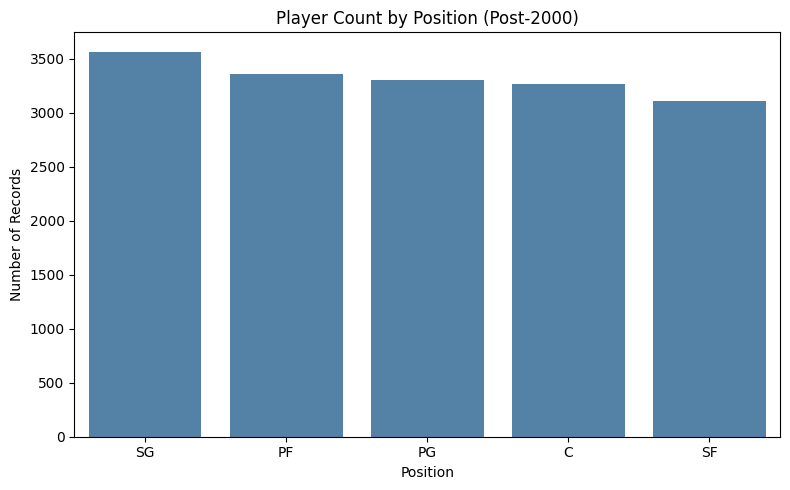

In [14]:
# 2A - Class Distribution
position_counts = df_clean['pos'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=position_counts.index, y=position_counts.values, color='steelblue')
plt.title('Player Count by Position (Post-2000)')
plt.xlabel('Position')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

/var/folders/2k/t_2h7z4s787d87f1f9_7pgpm0000gn/T/ipykernel_48097/1342034455.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='pos', y=feature,
/var/folders/2k/t_2h7z4s787d87f1f9_7pgpm0000gn/T/ipykernel_48097/1342034455.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='pos', y=feature,
/var/folders/2k/t_2h7z4s787d87f1f9_7pgpm0000gn/T/ipykernel_48097/1342034455.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='pos', y=feature,
/var/folders/2k/t_2h7z4s787d87f1f9_7pgpm0000gn/T/ipykernel

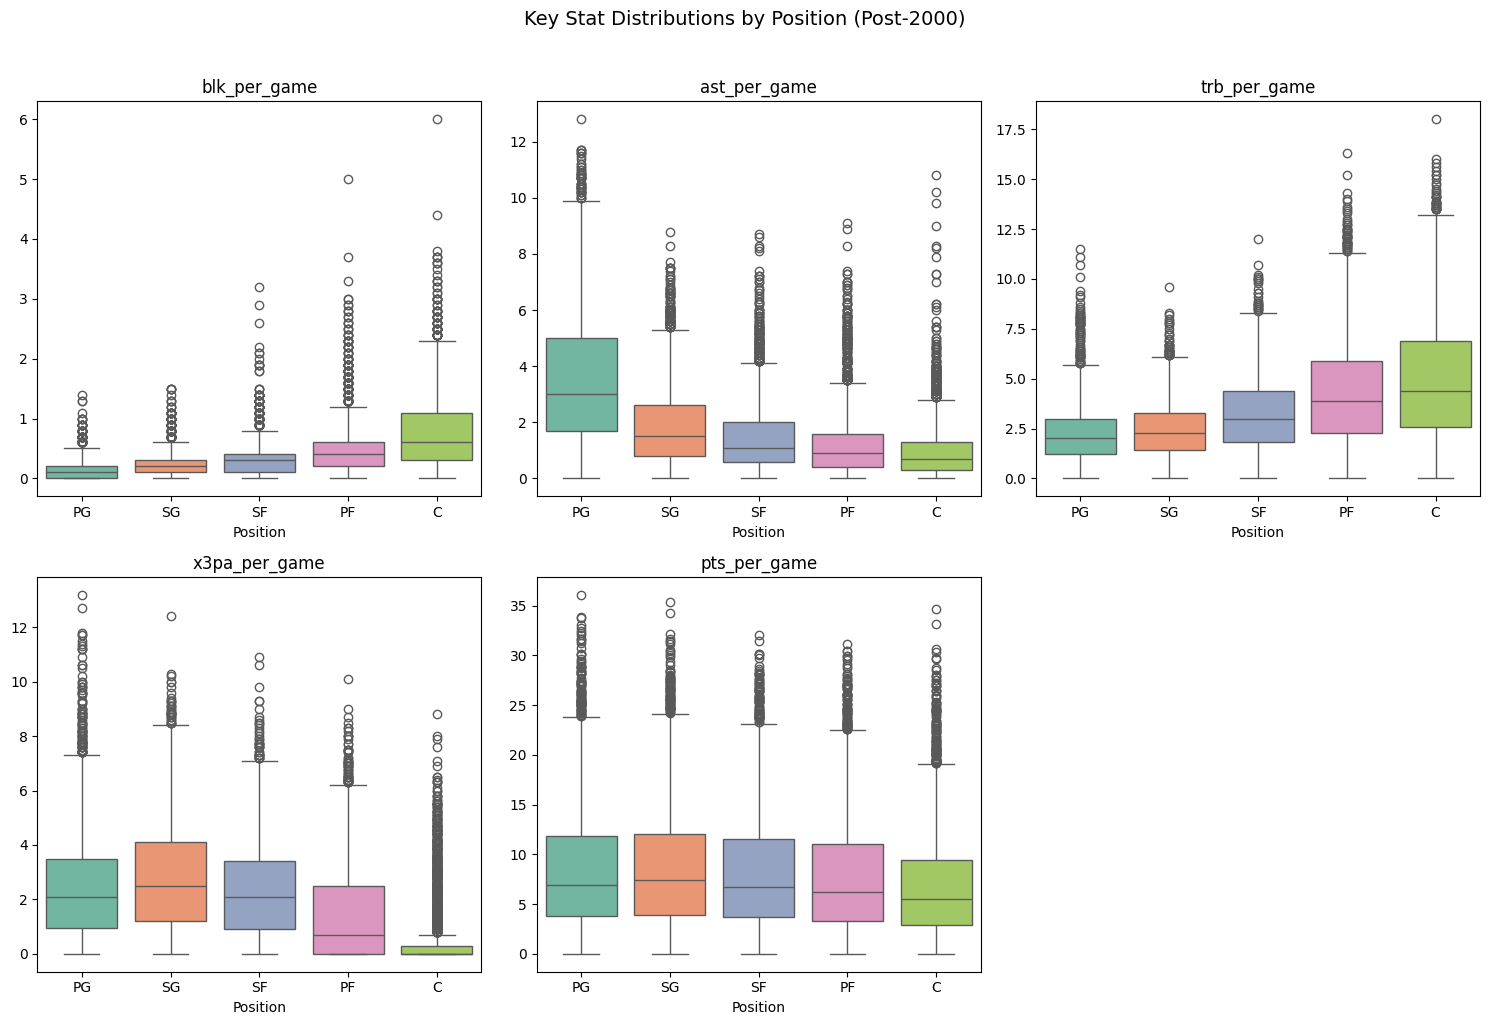

In [15]:
# 2B - Feature distributions by position
features = ['blk_per_game', 'ast_per_game', 'trb_per_game', 
            'x3pa_per_game', 'pts_per_game']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df_clean, x='pos', y=feature, 
                order=['PG', 'SG', 'SF', 'PF', 'C'],
                palette='Set2', ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel('Position')
    axes[i].set_ylabel('')

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle('Key Stat Distributions by Position (Post-2000)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

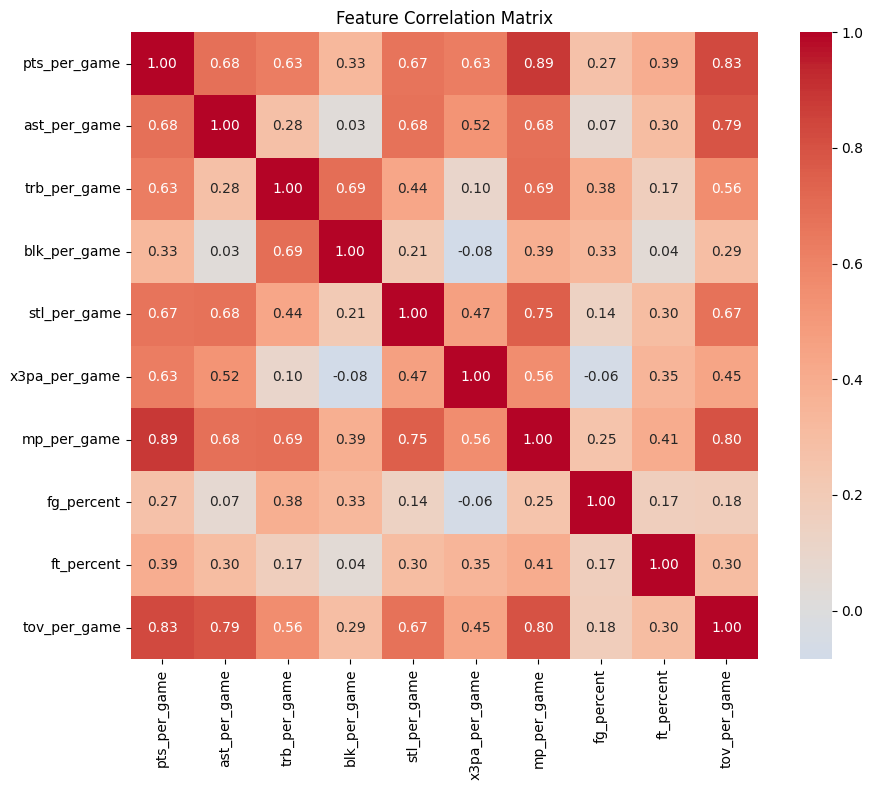

In [16]:
# 2C - Feature correlation matrix
features = ['pts_per_game', 'ast_per_game', 'trb_per_game', 'blk_per_game',
            'stl_per_game', 'x3pa_per_game', 'mp_per_game', 'fg_percent',
            'ft_percent', 'tov_per_game']

corr_matrix = df_clean[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [17]:
# Step 1 - Apply minimum minutes filter (removes garbage time players)
df_model = df_clean[df_clean['mp_per_game'] >= 5].copy()
print("After minutes filter:", df_model.shape)

# Step 2 - Select the 10 features
features = ['pts_per_game', 'ast_per_game', 'trb_per_game', 'blk_per_game',
            'stl_per_game', 'x3pa_per_game', 'mp_per_game', 'fg_percent',
            'ft_percent', 'tov_per_game']

X = df_model[features]
y = df_model['pos']

# Step 3 - Encode position labels as numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nPosition encoding:")
for i, label in enumerate(le.classes_):
    print(f"  {label} -> {i}")

print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y_encoded.shape)
print("\nAny nulls in X:", X.isnull().sum().sum())

After minutes filter: (15617, 32)

Position encoding:
  C -> 0
  PF -> 1
  PG -> 2
  SF -> 3
  SG -> 4

Feature matrix shape: (15617, 10)
Target vector shape: (15617,)

Any nulls in X: 0


In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

# Define classifiers
classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Stratified 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Train and evaluate each
results = {}
for name, clf in classifiers.items():
    scores = cross_validate(clf, X, y_encoded, cv=cv,
                           scoring=['accuracy', 'f1_macro'])
    results[name] = {
        'accuracy': scores['test_accuracy'].mean(),
        'f1_macro': scores['test_f1_macro'].mean()
    }
    print(f"{name}:")
    print(f"  Accuracy: {scores['test_accuracy'].mean():.3f}")
    print(f"  Macro F1: {scores['test_f1_macro'].mean():.3f}\n")

Decision Tree:
  Accuracy: 0.534
  Macro F1: 0.534

Naive Bayes:
  Accuracy: 0.482
  Macro F1: 0.457

Random Forest:
  Accuracy: 0.641
  Macro F1: 0.636



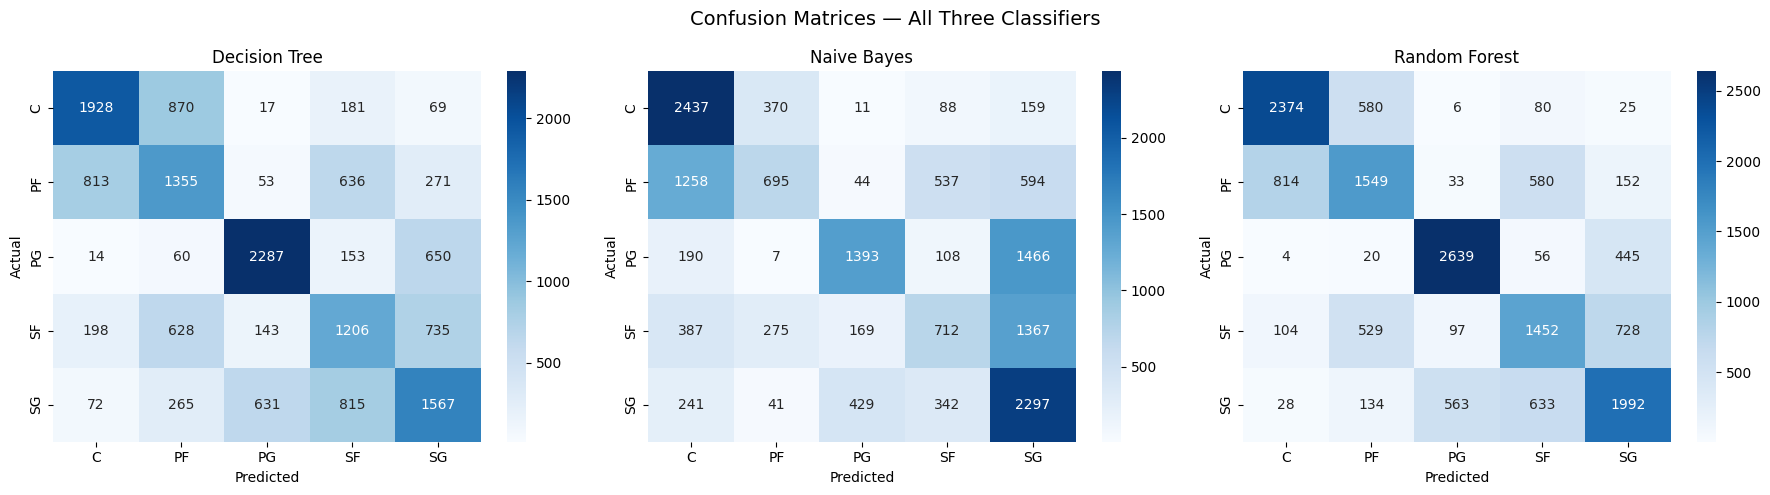

In [19]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

position_labels = le.classes_

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, clf) in zip(axes, classifiers.items()):
    y_pred = cross_val_predict(clf, X, y_encoded, cv=cv)
    cm = confusion_matrix(y_encoded, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=position_labels,
                yticklabels=position_labels,
                ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Three Classifiers', fontsize=14)
plt.tight_layout()
plt.show()